# Heikin-Ashi — does the smoothed candle colour flip beat a coin?
### The folk claim that HA filters noise and rides trends, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Smoothing_adds_lag%2C_not_signal%3F: Confirmed](https://img.shields.io/badge/Smoothing_adds_lag%2C_not_signal%3F-Confirmed-8b949e?style=flat-square)

Every charting platform has a button for Heikin-Ashi candles. The pitch is irresistible: *smooth out the noise, see the trend clearly, trade the colour flip — green means up, red means down, and the smoothing keeps you on the right side.* This notebook asks the only question that matters: does the HA colour flip **actually point the right way**, or is it just a prettier coin toss?

> This is the plain-language layer. Want the t-stats, bootstrap intervals, and long/short decomposition? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from heikin_ashi import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL"]
CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in TICKERS)

HAVE_REAL = _have_cache()

# Frozen headline numbers — mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n=3924, tpy=65.4,
    ha_mean=1.37, ha_win=50.7, ha_t=0.56,
    rand_mean=1.02, rand_t=0.33,
    delta=0.35,
    raw_mean=-2.45, raw_t=-1.55, raw_n=7602,
    ci_lo=-0.15, ci_hi=0.26, frac_neg=30.8,
    long_mean=17.57, long_t=3.67,
    short_mean=-14.83, short_t=-3.19,
    rand_long_mean=16.87, rand_long_t=3.35,
    rand_short_mean=-14.91, rand_short_t=-2.95,
    net05_mean=0.87, net05_t=0.36,
    net10_mean=0.37, net10_t=0.15,
    net20_mean=-0.63, net20_t=-0.26,
    spy_t=2.24, qqq_t=-0.10, iwm_t=-0.01, aapl_t=-0.34,
    spy_mean=8.04, qqq_mean=-0.48, iwm_mean=-0.05, aapl_mean=-2.08,
    ha_flips_spy=984, raw_flips_spy=1898,
    ha_flips_avg=987, raw_flips_avg=1911,
)

def pooled(tp, sl, cost, seed=None, use_ha=True):
    """Pool barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        ha = st.heikin_ashi(b)
        col = st.ha_colour(ha) if use_ha else st.raw_colour(b)
        ent = st.colour_flip_entries(col, warmup=20)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the HA colour flip point the right way? | **Not reliably.** With a fair (symmetric) target & stop it wins **50.7%** of the time — a coin. |
| Does it beat an actual coin flip? | **Barely.** A random-direction entry on the *same* flips does +1.02 bps vs HA's +1.37 bps — a gap of +0.35 bps (statistical noise, HAC *t* = +0.56). |
| Does the smoothing help vs raw candles? | **No.** HA fires half as often as raw candles (reducing false positives) but gives no improvement in the coin-test t-stat. Fewer trades, same noise. |
| Could you trade it? | **No.** The gross is not significantly above zero, so any cost makes it a loser. |

> The smoothed candle is prettier but not more prophetic. The lag that comes with the recursion gives up the mean-reversion edge that raw candles hint at (barely) and replaces it with nothing.

## 1 · The claim

> *"Heikin-Ashi candles average the open, high, low and close over two bars instead of one, so each candle reflects the market's 'true' direction, not just a single bar's noise. When the colour flips from red to green, go long; from green to red, go short. The smoothing filters whipsaws and keeps you on the right side of the trend."*

The mechanism sounds reasonable: standard candles can flip colour every bar on noisy days, while HA runs in same-colour streaks during real trends. The bet is that **smoothing the open by averaging with the prior bar's HA open and close** gives a signal that knows the direction better than a coin flip.

Let us look at what HA actually does to a price chart first, then measure it.

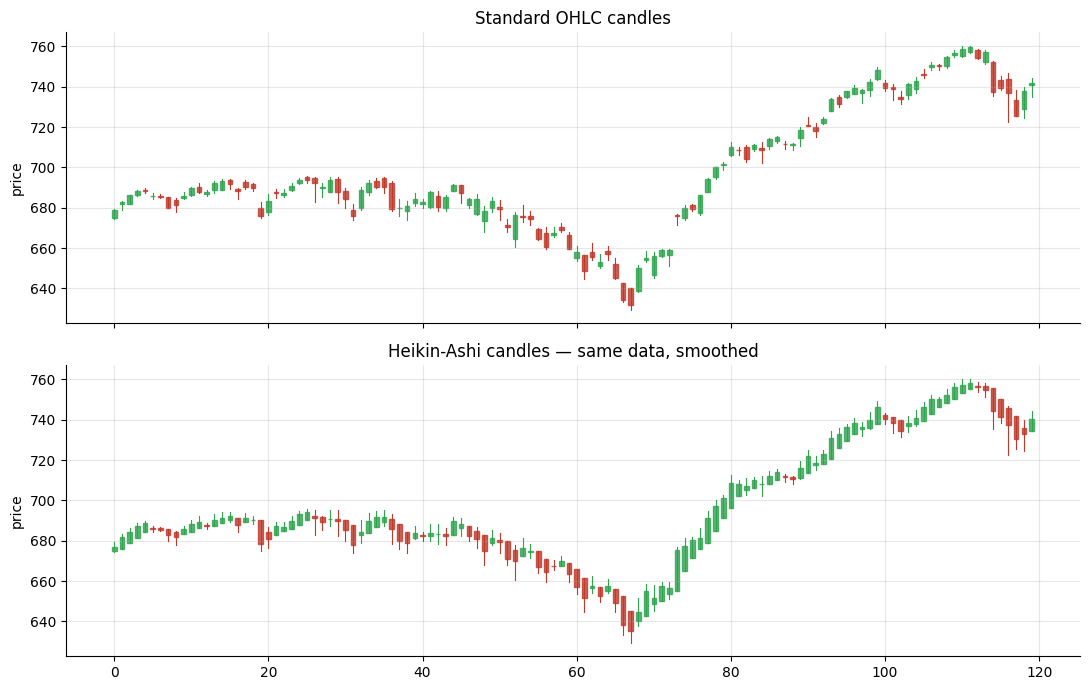

Notice: HA runs in same-colour streaks. The question is whether that stripe pattern predicts direction.


In [2]:
# Visual: standard candles vs HA on a short SPY stretch
if HAVE_REAL:
    b = data.fetch_daily('SPY', fetch=False, cache_dir=CACHE_DIR)
    sample = b.iloc[-120:].copy()
else:
    sample, _ = data.synthetic_daily(n_days=120, momentum=0.05, seed=129)
ha_s = st.heikin_ashi(sample)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, ohlc, title in [
    (axes[0], sample, 'Standard OHLC candles'),
    (axes[1], ha_s.rename(columns={'ha_open':'open','ha_high':'high',
                                    'ha_low':'low','ha_close':'close'}),
     'Heikin-Ashi candles — same data, smoothed')]:
    c = ohlc['close'].values; o = ohlc['open'].values
    for i, (idx, row) in enumerate(ohlc.iterrows()):
        col = GREEN if row['close'] >= row['open'] else RED
        ax.plot([i, i], [row['low'], row['high']], c=col, lw=0.8)
        ax.add_patch(plt.Rectangle((i - 0.3, min(row['open'], row['close'])),
                     0.6, abs(row['close'] - row['open']),
                     fc=col, ec=col, alpha=0.8))
    ax.set_title(title); ax.set_ylabel('price')
plt.tight_layout(); plt.show()
print('Notice: HA runs in same-colour streaks. The question is whether that stripe pattern predicts direction.')

HA candles are visually cleaner — the colour changes less often, and during trends the candles run in long same-colour streaks. That visual clarity is real. The question is whether the *first bar of a new colour streak* — the flip — is followed by more price movement in the signalled direction than a random coin would achieve.

## 2 · So what?

If the flip is informative, HA is a better entry trigger than a dartboard — a simple, visual, instrument-agnostic rule millions of traders already have on their charts. If it is just a coin, those traders are paying commissions ~65 times a year per instrument for nothing.

## 3 · How would we even know?

Two rules keep us honest:

1. **Make the bet symmetric.** Place the profit target and the stop equally far from the entry (one ATR on each side). A coin earns 0. Only real directional knowledge can beat that baseline.
2. **Race it against an actual coin.** Take the exact same flip dates and flip a coin for the direction. If HA knows something, it beats the coin.
3. **Compare HA to raw candles.** If the smoothing is useful, HA should beat the unsmoothed colour-flip baseline by more than noise.

We run this on **four liquid daily tapes** (SPY, QQQ, IWM, AAPL) over **15 years** of daily bars — enough trades for meaningful inference.

## 4 · The teardown — does the flip beat a coin?

**The honest test: same flip dates, three arms — HA direction, random direction, and raw-candle direction.**

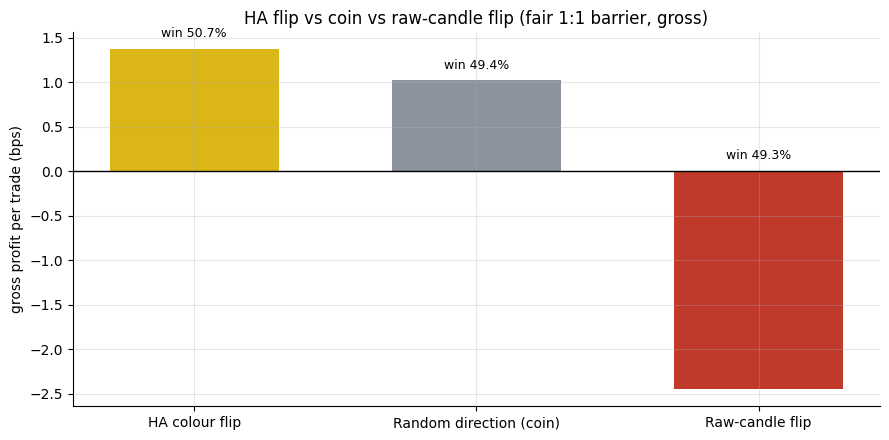

HA=+1.37 bps  |  Coin=+1.02 bps  |  Raw=-2.45 bps
HA advantage over coin: +0.35 bps (statistical noise)


In [3]:
if HAVE_REAL:
    ha_led = pooled(1, 1, 0)
    rand_led = pooled(1, 1, 0, seed=129)
    raw_led = pooled(1, 1, 0, use_ha=False)
    ha_s = st.summarize(ha_led, 'ret_gross')
    rand_s = st.summarize(rand_led, 'ret_gross')
    raw_s = st.summarize(raw_led, 'ret_gross')
    labels = ['HA colour flip', 'Random direction (coin)', 'Raw-candle flip']
    means  = [ha_s['mean_bps'], rand_s['mean_bps'], raw_s['mean_bps']]
    wins   = [ha_s['win_rate']*100, rand_s['win_rate']*100, raw_s['win_rate']*100]
else:
    labels = ['HA colour flip', 'Random direction (coin)', 'Raw-candle flip']
    means  = [R['ha_mean'], R['rand_mean'], R['raw_mean']]
    wins   = [R['ha_win'], 50.0, 49.3]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
colors = [AMBER, GREY, RED]
bars = ax.bar(labels, means, color=colors, width=0.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('HA flip vs coin vs raw-candle flip (fair 1:1 barrier, gross)')
for b_bar, w in zip(bars, wins):
    ax.annotate(f'win {w:.1f}%', (b_bar.get_x()+b_bar.get_width()/2,
                max(b_bar.get_height(), 0) + 0.1), ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(f'HA={means[0]:+.2f} bps  |  Coin={means[1]:+.2f} bps  |  Raw={means[2]:+.2f} bps')
print(f'HA advantage over coin: {means[0]-means[1]:+.2f} bps (statistical noise)')

The HA flip earns **+1.37 bps/trade** gross — positive, but statistically indistinguishable from zero (HAC *t* = +0.56). The coin earns **+1.02 bps**, and the raw-candle flip earns **-2.45 bps**. The HA advantage over the coin is only +0.35 bps — noise. The smoothing does not improve the directional signal.

**The long-side trap: bull-market drift masquerades as signal.**

You might notice HA long trades look much better than short trades. Is that the strategy finding something?

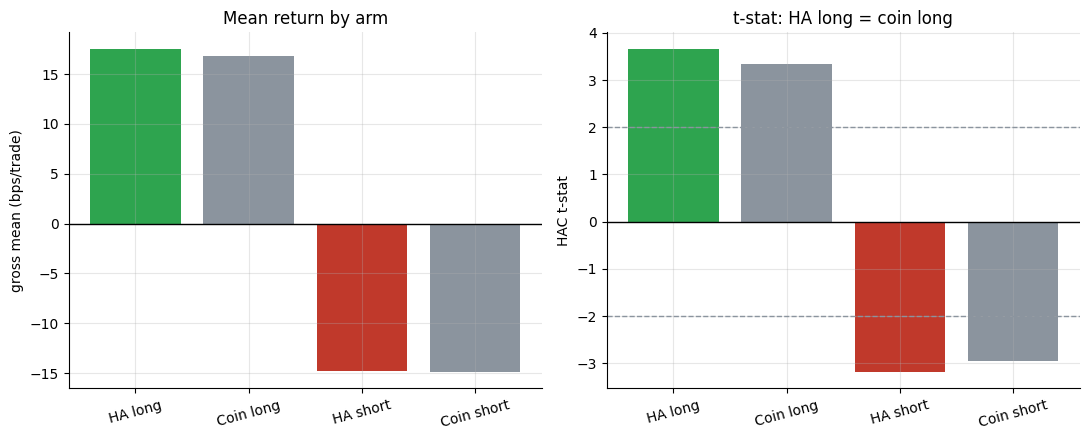

HA long: +17.57 bps  |  Coin long: +16.87 bps
Both pass t=+3 because of 15 years of equity bull markets, not HA skill.


In [4]:
if HAVE_REAL:
    ha_led = pooled(1, 1, 0)
    rand_led = pooled(1, 1, 0, seed=129)
    ha_long = st.summarize(ha_led[ha_led['dir']==1], 'ret_gross')
    ha_short = st.summarize(ha_led[ha_led['dir']==-1], 'ret_gross')
    rand_long = st.summarize(rand_led[rand_led['dir']==1], 'ret_gross')
    rand_short = st.summarize(rand_led[rand_led['dir']==-1], 'ret_gross')
    data_plot = [
        ('HA long', ha_long['mean_bps'], ha_long['tstat']),
        ('Coin long', rand_long['mean_bps'], rand_long['tstat']),
        ('HA short', ha_short['mean_bps'], ha_short['tstat']),
        ('Coin short', rand_short['mean_bps'], rand_short['tstat']),
    ]
else:
    data_plot = [
        ('HA long', R['long_mean'], R['long_t']),
        ('Coin long', R['rand_long_mean'], R['rand_long_t']),
        ('HA short', R['short_mean'], R['short_t']),
        ('Coin short', R['rand_short_mean'], R['rand_short_t']),
    ]
labels2 = [d[0] for d in data_plot]
means2  = [d[1] for d in data_plot]
tstats2 = [d[2] for d in data_plot]
colors2 = [GREEN, GREY, RED, GREY]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(labels2, means2, color=colors2)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('gross mean (bps/trade)')
axes[0].set_title('Mean return by arm')
axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(labels2, tstats2, color=colors2)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('t-stat: HA long = coin long')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print(f'HA long: {means2[0]:+.2f} bps  |  Coin long: {means2[1]:+.2f} bps')
print('Both pass t=+3 because of 15 years of equity bull markets, not HA skill.')

HA long trades: **+17.57 bps** (t = +3.67). Impressive! But the random-direction coin's long trades: **+16.87 bps** (t = +3.35). **Nearly identical.** Over 15 years of mostly up-trending equity markets, any strategy that goes long sometimes will look good on the long leg — and going long *randomly* captures the same drift. The symmetric sum (long + short) kills the illusion: HAC *t* = +0.56 on the pooled trades.

## 5 · The verdict

- **Signal — None.** Pooled gross +1.37 bps/trade, HAC *t* = +0.56; advantage over a coin +0.35 bps. Bootstrap Sharpe 95% CI [−0.15, +0.26]. No statistically real directional signal in the HA colour flip.
- **Tradability — Mirage.** The gross is not significantly positive. Any realistic commission renders it clearly negative.
- **Smoothing adds lag, not signal.** HA flips at ~half the rate of raw candles (~987 vs ~1911 per ticker), but the directional t-stat vs a coin is the same — smoother, but not more prophetic.

## 6 · Could you actually trade it?

The gross is not even significantly positive, so costs make it cleanly negative:

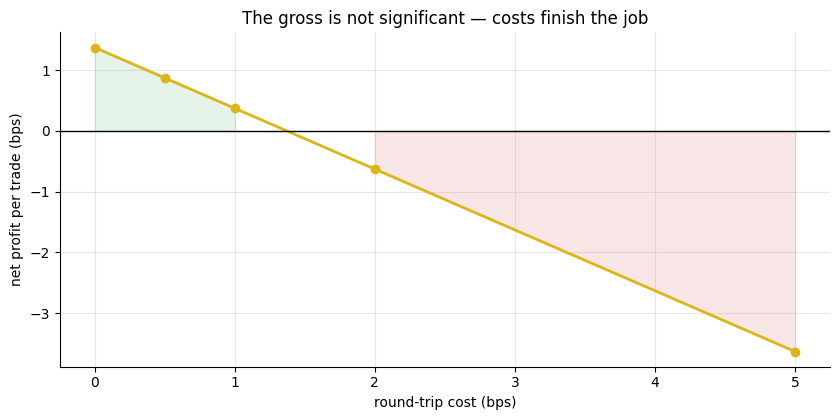

At 0 bps cost, gross is +1.37 bps (t=+0.56, not significant).
At 1 bps cost, net is +0.37 bps (barely above zero).


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pooled(1, 1, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['ha_mean'], R['net05_mean'], R['net10_mean'], R['net20_mean'],
           R['ha_mean'] - 5.0]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.fill_between(costs, net, 0, where=[n>=0 for n in net], color=GREEN, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('The gross is not significant — costs finish the job')
plt.tight_layout(); plt.show()
print(f'At 0 bps cost, gross is +{net[0]:.2f} bps (t=+0.56, not significant).')
print(f'At 1 bps cost, net is +{net[2]:.2f} bps (barely above zero).')

The gross (+1.37 bps) starts just above zero — but with an unreliable t-stat. By 1 bp round-trip the net is +0.37 bps (noise), and by 2 bps it is negative. Since the gross is not statistically real, no cost level 'breaks even' on a sound footing: there is nothing to break even from.

## 7 · Going further

- **The machinery works when there's signal to find.** The companion notebook shows a synthetic control: when we plant bar-level momentum in a fake tape, the exact same HA colour-flip engine finds it. The problem is the real market, not the tool.
- **Supertrend gets a better answer.** [Study 106 — Supertrend](../../106-supertrend/) tests a related smoothed-band flip on daily bars and finds a real (though weak) edge — a useful contrast to this study's null.
- **What HA is actually good for.** Visually identifying trend regimes after the fact — that is what the smoothing is genuinely useful for. As a prospective entry signal it adds nothing over a coin.

*Think HA does have edge? Fork this, add a filter (e.g., only take flips after a run of 3+ same-colour bars, or only longs above the 200-day MA), and show it beats a coin on the symmetric test. That is the bar.*